

---



---



## EJEMPLO Clasificar perros y gatos

https://www.youtube.com/watch?v=DbwKbsCWPSg


In [3]:
!pip install tensorflow_datasets

In [17]:
!pip install "numpy<2.0.0" --force-reinstall
!pip install "opencv-python<4.10" --force-reinstall


  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorflow-decision-forests 1.8.0 requires tensorflow~=2.15.0, but you have tensorflow 2.16.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 26.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 40.1 MB/s 

In [18]:
pip install "numpy<2.0.0" --force-reinstall


  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install "opencv-python<4.10" --no-deps --force-reinstall


  Using cached opencv_python-4.9.0.80-cp37-abi3-macosx_11_0_arm64.whl.metadata (20 kB)
Using cached opencv_python-4.9.0.80-cp37-abi3-macosx_11_0_arm64.whl (35.4 MB)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from tensorflow import keras
from keras.utils import load_img
from keras.utils import img_to_array
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
import tensorflow_datasets as tfds
import time
import matplotlib.pyplot as plt
import cv2

In [21]:
t = time.time()

In [22]:
#Tensorflow datasets tiene error al descargar el set de perros y gatos y lo solucionaron
#el 16 de mayo pero sigue fallando en los colabs. Entonces se agrega esta linea adicional
#Mas detalle aqui: https://github.com/tensorflow/datasets/issues/3918
setattr(tfds.image_classification.cats_vs_dogs, '_URL',"https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip")

In [23]:
#Descargar el set de datos de perros y gatos
datos, metadatos = tfds.load('cats_vs_dogs', as_supervised=True, with_info=True)

In [24]:
metadatos

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/Users/ivana/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douc

In [28]:
%pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,image,label
0,,1 (dog)
1,,1 (dog)
2,,1 (dog)

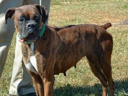
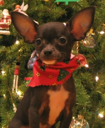
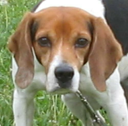

In [29]:
#Una forma de mostrar 5 ejemplos del set
tfds.as_dataframe(datos['train'].take(3), metadatos)

In [30]:
#Variable que contendra todos los pares de los datos (imagen y etiqueta) ya modificados (blanco y negro, 100x100)
datos_entrenamiento = []
TAMANO_IMG=100

In [31]:
for i, (imagen, etiqueta) in enumerate(datos['train']): #Todos los datos
  imagen = cv2.resize(imagen.numpy(), (TAMANO_IMG, TAMANO_IMG))
  imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
  imagen = imagen.reshape(TAMANO_IMG, TAMANO_IMG, 1) #Cambiar tamano a 100,100,1
  datos_entrenamiento.append([imagen, etiqueta])

In [32]:
#Ver cuantos datos tengo en la variable
len(datos_entrenamiento)

23262

In [33]:
#Preparar mis variables X (entradas) y y (etiquetas) separadas

X = [] #imagenes de entrada (pixeles)
y = [] #etiquetas (perro o gato)

for imagen, etiqueta in datos_entrenamiento:
  X.append(imagen)
  y.append(etiqueta)

### Normalizar las imagenes

In [34]:
#Normalizar los datos de las X (imagenes). Se pasan a numero flotante y dividen entre 255 para quedar de 0-1 en lugar de 0-255
import numpy as np

X = np.array(X).astype(float) / 255

In [35]:
#Convertir etiquetas en arreglo simple
y = np.array(y)

In [36]:
y

array([1, 1, 1, ..., 0, 1, 0])

In [37]:
X.shape

(23262, 100, 100, 1)

### Modelo 1

In [38]:
modeloDenso1 = keras.models.Sequential([
  Input(shape=(100, 100, 1)),
  Flatten( ),
  Dense(150, activation='relu'),
  Dense(150, activation='relu'),
  Dense(50, activation='relu'),
  Dense(1, activation='sigmoid')
])

In [39]:
modeloDenso1.compile( optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'] )

In [40]:
150*50+50


7550

In [41]:
modeloDenso1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 10000)             0         
                                                                 
 dense (Dense)               (None, 150)               1500150   
                                                                 
 dense_1 (Dense)             (None, 150)               22650     
                                                                 
 dense_2 (Dense)             (None, 50)                7550      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 1530401 (5.84 MB)
Trainable params: 1530401 (5.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [42]:
#Tiempo esperado: 16 mins  GPU
%time history_Denso1 = modeloDenso1.fit( X, y, batch_size = 32, validation_split = 0.15, epochs = 50, verbose=0 )

CPU times: user 3min 54s, sys: 1min 31s, total: 5min 26s
Wall time: 4min 43s


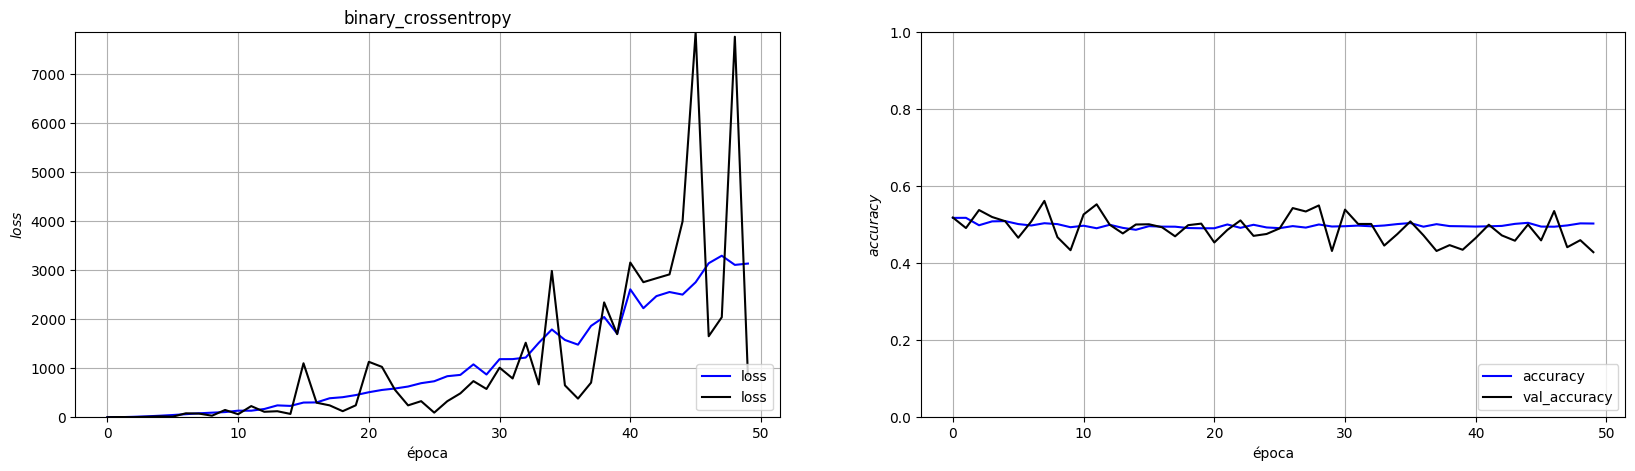

In [43]:
plt.figure( figsize=(20,5))

plt.subplot(1,2,1)
plt.plot(history_Denso1.epoch, history_Denso1.history['loss'], 'b',label='loss')
plt.plot(history_Denso1.epoch, history_Denso1.history['val_loss'], 'k',label='loss')
plt.title(u'binary_crossentropy')
plt.xlabel(u'época')
plt.ylabel(r'$loss$')
plt.ylim(0, max(max(history_Denso1.history['loss']),0.5+max(history_Denso1.history['val_loss'])))
plt.grid()
plt.legend(loc='lower right')


plt.subplot(1,2,2)
plt.plot(history_Denso1.epoch, history_Denso1.history['accuracy'], 'b',label='accuracy')
plt.plot(history_Denso1.epoch, history_Denso1.history['val_accuracy'], 'k',label='val_accuracy')
#plt.title(u'binary_crossentropy')
plt.xlabel(u'época')
plt.ylabel(r'$accuracy$')
plt.ylim(0,1)
plt.grid()
plt.legend(loc='lower right')
plt.show()

In [44]:
print(f'Tiempo de entrenamiento {(time.time() - t)/60:.5f} mins')

Tiempo de entrenamiento 5.94326 mins




---



---



# Exportar el modelo a TensorFlow.js

In [52]:
!source /Users/ivana/IA-projects/DogsCats/ClassifierDogsCats/nums/bin/activate


In [53]:
!pip install tensorflowjs --upgrade

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached tensorflow-2.15.1-cp311-cp311-macosx_12_0_arm64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.15.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
Using cached tensorflow-2.15.1-cp311-cp311-macosx_12_0_arm64.whl (205.7 MB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)
Using cached tensorboard-2.15.2-py3-none-any.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4
  Attempting uninstall: keras━━━━━━━━━━━━━━━━━━━ 0/4 [numpy]
    Found existing installation: keras 3.12.0 0/4 [numpy]
    Uninstalling keras-3.12.0:━━━━━━━━━━━━━━ 0/4 [numpy]
      Successfully uninstalled keras-3.12.0━ 0/4 [numpy]
  Attempting uninstall: tensorboard0m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [45]:
%pip install tensorflowjs


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [46]:
import sys
print("Python version:", sys.version)
import keras
print("Keras version:", keras.__version__)
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

Python version: 3.11.13 (main, Jun  3 2025, 18:38:25) [Clang 17.0.0 (clang-1700.0.13.3)]
Keras version: 2.15.0
TensorFlow version: 2.15.0


In [47]:
#Exportar el modelo en formato h5
modeloDenso1.save('clasificador_RegularNet.h5')

/Users/ivana/IA-projects/DogsCats/ClassifierDogsCats/nums/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [48]:
#Para convertirlo a tensorflow.js, primero debemos instalar la libreria
!pip install tensorflowjs --use-deprecated=legacy-resolver

In [49]:
#Crear carpeta donde se colocaran los archivos resultantes
!mkdir carpeta_salida

In [54]:
#Realizar la exportacion a la carpeta de salida
!tensorflowjs_converter --input_format keras clasificador_RegularNet.h5 carpeta_salida/regular

/Users/ivana/IA-projects/mnist_intento2/nums/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [32]:
#Confirmar que en la carpeta de salida se hayan generado los archivos. Deben aparecer archivos "bin" y "json"
!ls -la carpeta_salida

total 4
drwxr-xr-x. 2 lcc_rn_05 alumnos   10 Nov 11 17:59 .
drwxr-xr-x. 4 lcc_rn_05 alumnos 4096 Nov 11 18:01 ..


In [34]:
!rm /content/carpeta_salida/group1-shard1of1.bin

rm: cannot remove '/content/carpeta_salida/group1-shard1of1.bin': No such file or directory


In [35]:
!rm /content/carpeta_salida/model.json

rm: cannot remove '/content/carpeta_salida/model.json': No such file or directory
